# All Brackets — Cross-Season Rating Analysis
Fetch 2v2, 3v3, and shuffle brackets across 3 seasons to compare how rating distributions differ by bracket type.

In [3]:
import json
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def fetch_all(brackets: list[str], season_ids: list[int], regions: list[str] = ["us", "eu"], batch_size: int = 30) -> dict:
    """Fetch multiple bracket/season/region combos in batches to avoid rate limits."""
    script = '''
require "json"

brackets   = %w[''' + ' '.join(brackets) + ''']
season_ids = [''' + ', '.join(str(s) for s in season_ids) + ''']
regions    = %w[''' + ' '.join(regions) + ''']
locales    = { "us" => "en_US", "eu" => "en_GB" }
batch_size = ''' + str(batch_size) + '''

jobs = []
brackets.each do |bracket|
  season_ids.each do |sid|
    regions.each do |region|
      jobs << [bracket, sid, region]
    end
  end
end

$stderr.puts "#{jobs.size} total calls, batch_size=#{batch_size}"

results = {}
mutex   = Mutex.new

jobs.each_slice(batch_size).with_index do |batch, bi|
  $stderr.puts "  batch #{bi + 1}/#{(jobs.size.to_f / batch_size).ceil}..."
  threads = batch.map do |bracket, sid, region|
    Thread.new do
      begin
        data = Blizzard::Api::GameData::PvpSeason::Leaderboard.fetch(
          pvp_season_id: sid, bracket: bracket, region: region, locale: locales[region]
        )
        entries = data.fetch("entries", [])
        mutex.synchronize { results["#{bracket}|#{sid}|#{region}"] = entries }
      rescue => e
        $stderr.puts "    #{region}/#{bracket}/s#{sid}: ERROR #{e.message[0..80]}"
        mutex.synchronize { results["#{bracket}|#{sid}|#{region}"] = [] }
      end
    end
  end
  threads.each(&:join)
end

$stderr.puts "done"
puts results.to_json
'''
    r = subprocess.run(
        ['bundle', 'exec', 'rails', 'runner', '-'],
        input=script, capture_output=True, text=True, cwd='..', timeout=300
    )
    if r.returncode != 0:
        print(f"Error: {r.stderr[:500]}")
        return {}
    print(r.stderr)
    return json.loads(r.stdout)

In [4]:
SEASONS = {41: "Midnight S1", 40: "TWW S3", 39: "TWW S2"}

# Discover all brackets from current season
print("Discovering brackets...")
disc_script = 'puts Blizzard::Api::GameData::PvpSeason::LeaderboardsIndex.fetch(pvp_season_id: PvpSeason.current.blizzard_id, region: "us").to_json'
r = subprocess.run(['bundle', 'exec', 'rails', 'runner', '-'], input=disc_script, capture_output=True, text=True, cwd='..')
all_brackets = [lb['name'] for lb in json.loads(r.stdout).get('leaderboards', [])]

# Keep arena + shuffle only
SKIP_PREFIXES = ('blitz-', 'rbg')
SKIP_EXACT = {'shuffle-overall', 'blitz-overall'}
BRACKETS = [b for b in all_brackets if b not in SKIP_EXACT and not any(b.startswith(p) for p in SKIP_PREFIXES)]
print(f"Found {len(BRACKETS)} brackets: 2v2, 3v3 + {len([b for b in BRACKETS if b.startswith('shuffle-')])} shuffle specs")

Discovering brackets...
Found 42 brackets: 2v2, 3v3 + 40 shuffle specs


In [7]:
# ~41 brackets x 3 seasons x 2 regions = ~246 concurrent fetches
print(f"Fetching {len(BRACKETS)} brackets x {len(SEASONS)} seasons x 2 regions = {len(BRACKETS)*len(SEASONS)*2} calls...")
raw = fetch_all(BRACKETS, list(SEASONS.keys()))

all_rows = []
for key, entries in raw.items():
    bracket, sid_str, region = key.split("|")
    sid = int(sid_str)
    label = SEASONS[sid]
    for e in entries:
        all_rows.append({
            'bracket': bracket,
            'season': label,
            'season_id': sid,
            'region': region,
            'rank': e['rank'],
            'rating': e['rating'],
            'wins': e.get('season_match_statistics', {}).get('won', 0),
            'losses': e.get('season_match_statistics', {}).get('lost', 0),
        })

df = pd.DataFrame(all_rows)

# Summary table
summary = (
    df.groupby(['bracket', 'season', 'region'])
    .agg(entries=('rating', 'size'), min_rating=('rating', 'min'), max_rating=('rating', 'max'))
    .reset_index()
)
summary['rating_range'] = summary['min_rating'].astype(str) + '–' + summary['max_rating'].astype(str)
summary = summary.drop(columns=['min_rating', 'max_rating']).sort_values(['bracket', 'season', 'region'])

pd.set_option('display.max_rows', 300)
summary

Fetching 42 brackets x 3 seasons x 2 regions = 252 calls...
252 total calls, batch_size=30
  batch 1/9...
  batch 2/9...
    eu/shuffle-demonhunter-devourer/s39: ERROR Blizzard API error: HTTP 404, body={"code":404,"type":"BLZWEBAPI00000404","detail
    us/shuffle-demonhunter-devourer/s39: ERROR Blizzard API error: HTTP 404, body={"code":404,"type":"BLZWEBAPI00000404","detail
  batch 3/9...
  batch 4/9...
  batch 5/9...
  batch 6/9...
  batch 7/9...
  batch 8/9...
  batch 9/9...
done



,bracket,season,region,entries,rating_range
0,2v2,Midnight S1,eu,5013,1616–2252
1,2v2,Midnight S1,us,5011,1611–2332
2,2v2,TWW S2,eu,5026,2138–2830
3,2v2,TWW S2,us,5073,2114–2821
4,2v2,TWW S3,eu,5027,2179–2926
5,2v2,TWW S3,us,5008,2164–2887
6,3v3,Midnight S1,eu,5005,1544–2484
7,3v3,Midnight S1,us,5004,1571–2485
8,3v3,TWW S2,eu,5015,2171–3252
9,3v3,TWW S2,us,5006,2198–3215


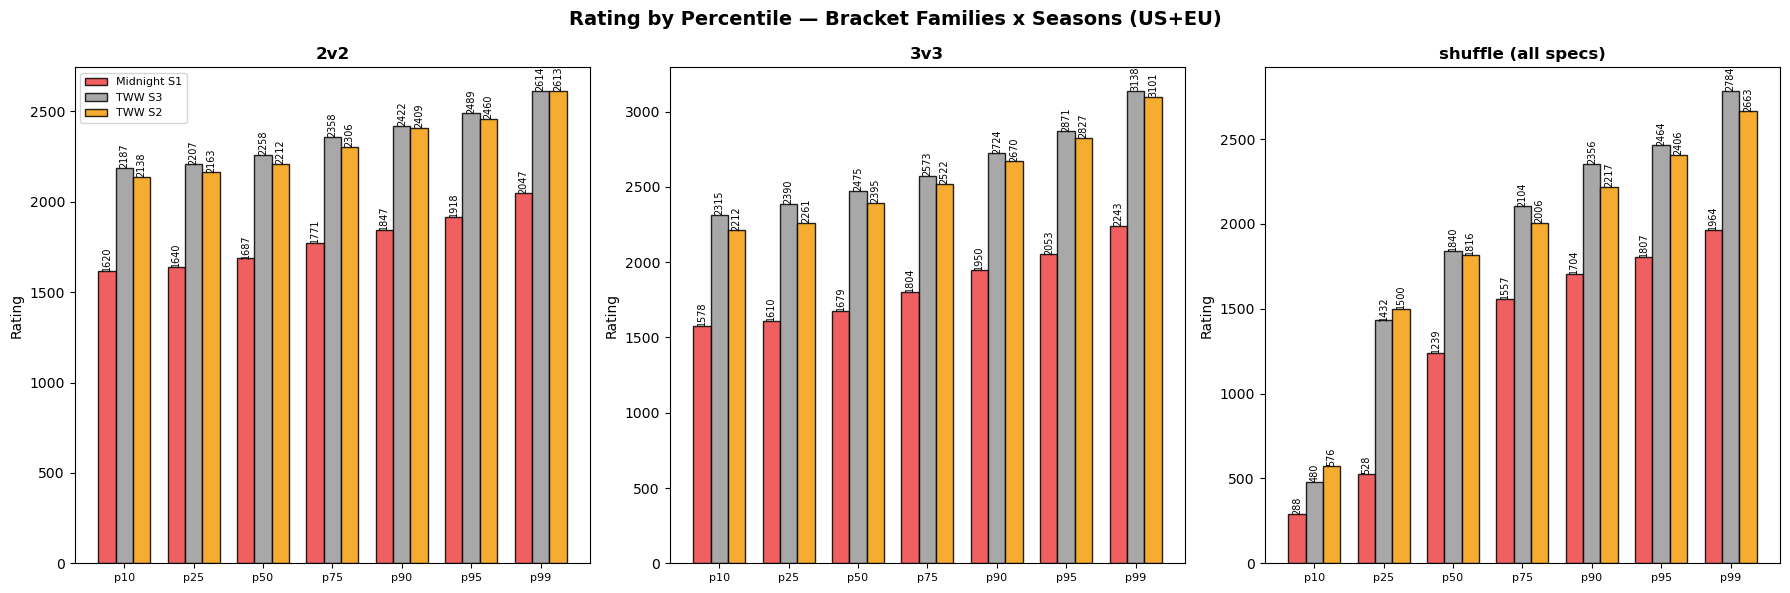

In [8]:
# Percentile comparison: group brackets into families (arena vs shuffle)
# Compare aggregated distributions across seasons
percentiles = [10, 25, 50, 75, 90, 95, 99]
season_colors = {'Midnight S1': '#ef4444', 'TWW S3': '#999', 'TWW S2': '#f59e0b'}

def bracket_family(b):
    if b in ('2v2', '3v3'):
        return b
    if b.startswith('shuffle-'):
        return 'shuffle (all specs)'
    return 'other'

df['family'] = df['bracket'].apply(bracket_family)
families = ['2v2', '3v3', 'shuffle (all specs)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for idx, family in enumerate(families):
    ax = axes[idx]
    fdf = df[df.family == family]
    x = np.arange(len(percentiles))
    width = 0.25

    for i, (sid, label) in enumerate(SEASONS.items()):
        sdf = fdf[fdf.season == label]
        if sdf.empty:
            continue
        vals = [sdf.rating.quantile(p / 100) for p in percentiles]
        bars = ax.bar(x + i * width, vals, width, label=label,
                      color=season_colors.get(label, '#999'), edgecolor='black', alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                    f'{v:.0f}', ha='center', fontsize=7, rotation=90)

    ax.set_xticks(x + width)
    ax.set_xticklabels([f'p{p}' for p in percentiles], fontsize=8)
    ax.set_title(family, fontsize=12, fontweight='bold')
    ax.set_ylabel('Rating')
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('Rating by Percentile — Bracket Families x Seasons (US+EU)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Key insight: how many players does current rating_min capture per bracket family?
def get_rating_min(bracket):
    if bracket == '2v2': return 2200
    if bracket == '3v3': return 2500
    if bracket.startswith('shuffle-'): return 2000
    return 1800

rows = []
for bracket in BRACKETS:
    rating_min = get_rating_min(bracket)
    for sid, label in SEASONS.items():
        bdf = df[(df.bracket == bracket) & (df.season_id == sid)]
        if bdf.empty:
            continue
        total = len(bdf)
        above = (bdf.rating >= rating_min).sum()
        pct = above / total * 100
        rows.append({
            'bracket': bracket,
            'season': label,
            'rating_min': rating_min,
            'total': total,
            'captured': above,
            '% captured': round(pct, 1),
        })

capture_df = pd.DataFrame(rows)

def highlight_low(val):
    if isinstance(val, (int, float)) and val < 10:
        return 'color: red; font-weight: bold'
    return ''

capture_df.style.map(highlight_low, subset=['% captured']).format({'% captured': '{:.1f}%'})

,bracket,season,rating_min,total,captured,% captured
0,2v2,Midnight S1,2200,10024,9,0.1%
1,2v2,TWW S3,2200,10035,8342,83.1%
2,2v2,TWW S2,2200,10099,5971,59.1%
3,3v3,Midnight S1,2500,10009,0,0.0%
4,3v3,TWW S3,2500,10006,4227,42.2%
5,3v3,TWW S2,2500,10021,2940,29.3%
6,shuffle-deathknight-blood,Midnight S1,2000,290,0,0.0%
7,shuffle-deathknight-blood,TWW S3,2000,1394,65,4.7%
8,shuffle-deathknight-blood,TWW S2,2000,1059,49,4.6%
9,shuffle-deathknight-frost,Midnight S1,2000,2182,17,0.8%


In [10]:
# Sample size per shuffle spec across seasons (US+EU combined)
shuffle_df = df[df.bracket.str.startswith('shuffle-')].copy()
shuffle_df['spec'] = shuffle_df['bracket'].str.replace('shuffle-', '')

sample = (
    shuffle_df.groupby(['spec', 'season'])
    .agg(total=('rating', 'size'), median_rating=('rating', 'median'))
    .reset_index()
    .pivot(index='spec', columns='season', values=['total', 'median_rating'])
)

# Flatten column names
sample.columns = [f'{stat}_{season}' for stat, season in sample.columns]
sample = sample.sort_values(f'total_{list(SEASONS.values())[0]}', ascending=False)

# Highlight thin data
def highlight_thin(val):
    if isinstance(val, (int, float)) and val < 200:
        return 'color: red; font-weight: bold'
    return ''

styled = sample.style.map(highlight_thin, subset=[c for c in sample.columns if c.startswith('total_')])
styled.format('{:.0f}')

,total_Midnight S1,total_TWW S2,total_TWW S3,median_rating_Midnight S1,median_rating_TWW S2,median_rating_TWW S3
spec,,,,,,
paladin-retribution,10233,10011,10012,1417,2035,2158
priest-discipline,10201,10031,10016,1468,2019,2203
paladin-holy,10141,10005,10032,1282,1931,2005
deathknight-unholy,9914,10249,10028,1330,1607,2067
monk-mistweaver,9898,10001,10073,1417,1811,1809
rogue-subtlety,9636,10177,9877,1336,1645,864
mage-frost,9030,10006,10000,1176,1872,1502
druid-restoration,7394,10008,10014,784,1812,1761
warrior-fury,7305,10015,10004,1134,1844,1845


In [11]:
# What would top_n-only look like? Compare current system vs proposed
cases = [
    ('2v2', 2200, 1000),
    ('3v3', 2500, 1000),
    ('shuffle-paladin-retribution', 2000, 500),  # popular spec
    ('shuffle-rogue-subtlety', 2000, 500),        # popular spec
    ('shuffle-demonhunter-vengeance', 2000, 500),  # tank (thin data)
    ('shuffle-evoker-augmentation', 2000, 500),    # niche (thin data)
    ('shuffle-mage-arcane', 2000, 500),            # low pop
]

rows = []
for bracket, current_min, proposed_top_n in cases:
    for sid, label in SEASONS.items():
        bdf = df[(df.bracket == bracket) & (df.season_id == sid)]
        if bdf.empty:
            continue
        total = len(bdf)

        # Current: top_n + rating_min
        current_top_n = 2500 if bracket in ('2v2', '3v3') else 1000
        current = bdf[bdf.rating >= current_min].nlargest(current_top_n, 'rating')
        current_count = len(current)
        current_floor = current.rating.min() if len(current) > 0 else None

        # Proposed: top_n only
        proposed = bdf.nlargest(proposed_top_n, 'rating')
        proposed_count = len(proposed)
        proposed_floor = proposed.rating.min() if len(proposed) > 0 else None

        rows.append({
            'bracket': bracket,
            'season': label,
            'leaderboard': total,
            'current_synced': current_count,
            'current_floor': current_floor,
            'proposed_synced': proposed_count,
            'proposed_floor': proposed_floor,
            'gain': proposed_count - current_count,
        })

compare = pd.DataFrame(rows)

def highlight_gain(val):
    if isinstance(val, (int, float)) and val > 0:
        return 'color: green; font-weight: bold'
    return ''

compare.style.map(highlight_gain, subset=['gain']).format({
    'current_floor': '{:.0f}', 'proposed_floor': '{:.0f}'
})

,bracket,season,leaderboard,current_synced,current_floor,proposed_synced,proposed_floor,gain
0,2v2,Midnight S1,10024,9,2200,1000,1847,991
1,2v2,TWW S3,10035,2500,2358,1000,2423,-1500
2,2v2,TWW S2,10099,2500,2307,1000,2410,-1500
3,3v3,Midnight S1,10009,0,nan,1000,1950,1000
4,3v3,TWW S3,10006,2500,2573,1000,2725,-1500
5,3v3,TWW S2,10021,2500,2523,1000,2671,-1500
6,shuffle-paladin-retribution,Midnight S1,10233,81,2000,500,1837,419
7,shuffle-paladin-retribution,TWW S3,10012,1000,2483,500,2618,-500
8,shuffle-paladin-retribution,TWW S2,10011,1000,2412,500,2484,-500
9,shuffle-rogue-subtlety,Midnight S1,9636,121,2000,500,1839,379


## Conclusions

### The Problem
Hardcoded `rating_min` thresholds (2200 for 2v2, 2500 for 3v3, 2000 for shuffle) filter out nearly all players in early season. Only 9 out of 10,024 2v2 players (US+EU) passed the 2200 floor. 3v3 captured **zero** players at 2500.

### Key Findings

1. **Rating distribution shape is consistent across seasons** — the spread between percentiles stays ~400 rating regardless of season maturity. The entire curve shifts upward as the season progresses.

2. **Shuffle has a much wider spread than arena** — p10 can be as low as 88 (current) vs 1620 for 2v2. Shuffle includes many casual/low-rated players.

3. **Mature seasons stabilize at ~10k entries** for popular specs. Tank/niche specs (Vengeance DH, Aug Evoker, Prot Warrior, Blood DK, Brewmaster) inherently have 100-500 entries regardless of season maturity.

4. **EU and US distributions are similar** — no need for region-specific thresholds.

5. **`top_n`-only gives full 500/1000 samples for 95% of brackets** across all seasons. Only 2 specs fall below 200 in early season: Vengeance DH (115) and Aug Evoker (176).

6. **500 players is statistically sufficient** for item/talent aggregation — a 20% usage item has 100 occurrences. Even 115 players produces usable (if noisy) meta data.

### Implementation

**Remove `rating_min` from `BracketConfig`. Use `top_n` as the sole limiter.**

| Family | `top_n` | Rationale |
|--------|---------|-----------|
| 2v2 | 1000 | 10k+ leaderboard, 1000 captures top 10% |
| 3v3 | 1000 | Same — solid sample for class-agnostic aggregation |
| shuffle | 500 | Per-spec brackets, 500 is top 5-50% depending on spec popularity |

- No `rating_min` needed — `top_n` naturally adapts to season maturity
- Thin specs (<200 entries) should show a "limited data" badge on the frontend
- No per-region or per-season tuning required